# Chapter 01 — First Simulation: a LAMMPS melt end to end, through the checker's fourteen rules

*lammps-skill 0.1.14. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter01_first_simulation.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)
6. [](#)
7. [](#)
8. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

from IPython.display import display, HTML

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

_FIG = {"n": 0}                # this chapter's own figure count -- chapters are self-contained

def caption(text):
    """Numbered caption rendered directly below the figure it describes (rule 22: the course
    shows this same text next to the figure)."""
    _FIG["n"] += 1
    display(HTML(
        "<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        "color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        "<b>Figure %d.</b> %s</div>" % (_FIG["n"], text)))

lammps-skill 0.1.14 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## End to end: `Spec` -> `check` -> `run` -> read the log -> plot

This chapter builds one case -- a Lennard-Jones melt, reduced units -- the whole way: a Python
`Spec`, rendered to a real input script, checked before anything runs, run through
`run_or_load` (record-or-run, S11), and its thermo output read back and plotted. Every step uses
`lammpskill`, nothing is copied from an upstream example (rule 7).

## The checker, one rule at a time

`lammpskill.script.check()` has fourteen rules, each pointing at the manual page it comes from.
Rather than trust a description, this cell builds one minimal snippet per rule -- deliberately
broken in exactly the way that rule catches -- and confirms the checker actually catches it.

In [2]:
import os
import tempfile

from lammpskill.script import CHECKS, check

# one minimal, deliberately-flawed snippet per rule. C14 also needs an (empty) workdir.
SNIPPETS = {
    "C01": "atom_style atomic\nrun 10\n",                                          # no `units`
    "C02": "units real\npair_style lj/cut/coul/long 10.0\nrun 10\n",               # coul/long, no kspace
    "C03": "units real\nkspace_style pppm 1e-4\npair_style lj/cut 10.0\nrun 10\n", # kspace, no long pair
    "C04": "units lj\ntimestep 0.1\n",                                              # 0.1 > lj's 0.01
    "C05": "units lj\nrun 10\n",                                                    # run before pair_style
    "C06": "units lj\npair_coeff 1 1 1.0 1.0\npair_style lj/cut 2.5\n",             # coeff before style
    "C07": "units lj\nfix 1 all nve\nfix 1 all langevin 1 1 1 1\n",                 # fix 1 reused, no unfix
    "C08": "units real\natom_style molecular\nrun 10\n",                           # molecular, no read_data
    "C09": "units lj\nthermo 1000\nrun 10\n",                                      # thermo > run
    "C10": "units lj\ndump 1 all atom 1000 out.dump\nrun 10\n",                    # dump every > run
    "C11": "units lj\ncreate_box 1 mybox\nvelocity all create 1.0 12345\n",         # velocity before mass
    "C12": "units lj\npair_style lj/cut 2.5\npair_coeff 1 1 1.0 1.0\nrun 10\n",    # no timestep
    "C13": "units lj\ntimestep 0.005\npair_style lj/cut 2.5\npair_coeff 1 1 1.0 1.0\nrun 10\n",  # writes nothing
    "C14": "units lj\nread_data missing.data\n",                                    # file absent
}
empty_workdir = tempfile.mkdtemp(prefix="ch01_c14_")

triggered, missed = [], []
for code_, snippet in SNIPPETS.items():
    findings = check(snippet, workdir=empty_workdir if code_ == "C14" else None)
    codes = [f.code for f in findings]
    (triggered if code_ in codes else missed).append(code_)

print("%d/%d rules triggered by their own minimal snippet" % (len(triggered), len(SNIPPETS)))
if missed:
    print("missed:", missed)
os.rmdir(empty_workdir)

14/14 rules triggered by their own minimal snippet


## Building the case: a `Spec`, not a hand-typed script

`lammpskill.script.lj_melt()` is a preset `Spec` -- reduced units, an FCC lattice at the melt
density `rho=0.8442`, 4000 atoms by default. `render()` turns it into the actual input text, in the
order the manual's *Commands_structure* page prescribes.

In [3]:
from lammpskill.script import check, lj_melt, render

spec = lj_melt()   # n=10 (4000 atoms), rho=0.8442, T=3.0, steps=250 -- the case tests/fixtures/log_lj_melt.lammps records
text = render(spec)
print(text)

# generated by lammps-skill 0.1.14 — Lennard-Jones melt, reduced units

# --- initialization
units lj
dimension 3
boundary p p p
atom_style atomic

# --- system definition
lattice fcc 0.8442
region box block 0 10 0 10 0 10
create_box 1 box
create_atoms 1 box
mass 1 1

# --- settings
pair_style lj/cut 2.5
pair_coeff 1 1 1.0 1.0 2.5
neighbor 0.3 bin
neigh_modify every 20 delay 0 check no
velocity all create 3 87287 loop geom
fix 1 all nve
thermo 50
thermo_style custom step temp epair emol etotal press

# --- run
run 250



## Checking the case before it runs

The preset is not hand-tuned to dodge the checker -- it is checked the same way the broken
snippets above were, and only the two *info*-level findings remain: no explicit `timestep` (the
`lj` default, 0.005, applies) and nothing written at the end. Neither is an error; both are worth
knowing before the run starts.

In [4]:
findings = check(text)
for f in findings:
    print(f.level.upper(), f.code, "--", f.message)
assert all(f.level != "error" for f in findings), "the preset case should not carry a checker error"

INFO C12 -- no `timestep`: the default for these units applies (lj 0.005, real 1.0, metal 0.001)
INFO C13 -- nothing written at the end (`write_data`, `write_restart` or a dump)


## Running it: record-or-run

`run_or_load` is the one call every later chapter uses: with a LAMMPS installation present, it
runs the case for real and writes the record; without one, it loads whatever record already
exists. The case above is exactly `tests/fixtures/log_lj_melt.lammps` (4000 atoms, 250 steps), so a
reader with no LAMMPS still sees a real result -- just not a freshly computed one.

In [5]:
import tempfile

from lammpskill.run import run, run_or_load


def compute():
    workdir = tempfile.mkdtemp(prefix="ch01_lj_melt_")
    result = run(spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("LJ melt run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    t = result.thermo
    return {
        "natoms": t.natoms, "nsteps": t.nsteps, "loop_time": t.loop_time,
        "route": result.installation.route if result.installation else None,
        "lammps_version": result.installation.version if result.installation else None,
        "columns": t.columns,
        "series": {c: [float(x) for x in t.get(c)] for c in t.columns},
        "final": t.last,
    }


rec = run_or_load("lj_melt_ch01", compute, records_dir="../data/records")
print("source:", rec["source"], "| natoms:", rec.get("natoms"), "| nsteps:", rec.get("nsteps"))
if rec["source"] != "skip":
    print("route:", rec.get("route"), rec.get("lammps_version"), "| loop_time:", rec.get("loop_time"))
    print("final row:", rec.get("final"))
else:
    print("no LAMMPS available and no record yet:", rec.get("reason"))

source: record | natoms: 4000 | nsteps: 250
route: wsl-apt 10 Dec 2025 | loop_time: 0.682492
final row: {'E_mol': 0.0, 'E_pair': -4.7774327, 'Press': 5.7526089, 'Step': 250.0, 'Temp': 1.6645597, 'TotEng': -2.2812174}


## Reading the log, plotted

`Result.thermo` is the same `ThermoRun` chapter 08 reads from a log file directly -- `run()`
already parsed it. The record stores the full column series, so the plot below is real thermo
output whether this run happened just now or was loaded from disk.

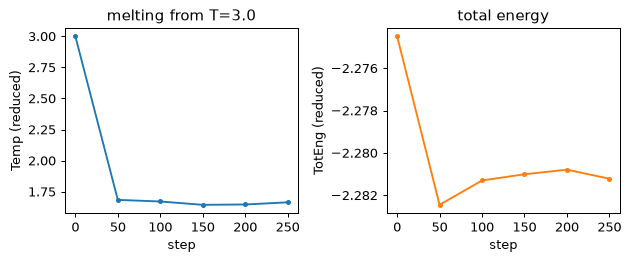

In [6]:
import matplotlib.pyplot as plt

if rec["source"] != "skip":
    step, temp, etot = rec["series"]["Step"], rec["series"]["Temp"], rec["series"]["TotEng"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), dpi=90)
    ax1.plot(step, temp, marker="o", ms=3)
    ax1.set_xlabel("step"); ax1.set_ylabel("Temp (reduced)"); ax1.set_title("melting from T=3.0")
    ax2.plot(step, etot, marker="o", ms=3, color="tab:orange")
    ax2.set_xlabel("step"); ax2.set_ylabel("TotEng (reduced)"); ax2.set_title("total energy")
    fig.tight_layout()
    plt.show()
    caption("The LJ melt's thermo history read back from the log: temperature falling away "
            "from the T=3.0 start (left) while the total energy holds flat (right) -- the two "
            "curves run() reads out of LAMMPS's own thermo output, whether this cell just ran "
            "the case or loaded a stored record.")
else:
    print("nothing to plot: no LAMMPS and no record")

## Watching the melt happen

Every plot so far has been a *derived* quantity -- temperature, energy -- read out of LAMMPS's
thermo output. This section shows the atoms themselves: the same physical case
(`lj_melt()`'s FCC lattice, `rho=0.8442`, reduced units), run once more with a trajectory dump
added, so the checker's fourteen rules, the rendered script, and the thermo curves above all
describe something you can also just look at.

In [7]:
import os
import tempfile

import numpy as np

from lammpskill.io.dump import read_dump
from lammpskill.run import run, run_or_load
from lammpskill.script import Spec, Stage

DUMP_EVERY = 25
N_ATOMS_SHOWN = 200   # a subsample of the real 4000-atom run, not the whole trajectory -- chapter
                       # 06 already found (and fixed) that storing a full raw trajectory in a
                       # committed record costs megabytes for no benefit a rendered figure needs
N_FRAMES = 10

traj_spec = Spec(
    units="lj", atom_style="atomic", lattice="fcc 0.8442", region="box block 0 10 0 10 0 10",
    create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
    neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
    velocity=["all create 3.0 87287 loop geom"], timestep=0.005, fixes=["1 all nve"],
    dumps=["1 all custom %d traj.dump id type xu yu zu" % DUMP_EVERY],
    thermo=50, thermo_style="custom step temp epair emol etotal press",
    stages=[Stage("run", "250")], comment="the same LJ melt as above, with a trajectory dump for the atom views",
)


def compute_traj():
    workdir = tempfile.mkdtemp(prefix="ch01_traj_")
    result = run(traj_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("trajectory run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    traj = read_dump(os.path.join(workdir, "traj.dump"))
    rng = np.random.default_rng(0)
    natoms = traj.frames[0].natoms
    idx = rng.choice(natoms, size=min(N_ATOMS_SHOWN, natoms), replace=False)
    step = max(1, len(traj) // N_FRAMES)
    frames = [f.positions[idx].tolist() for f in traj.frames[::step]]
    return {"natoms_shown": len(idx), "nframes": len(frames), "frames": frames,
            "cell": traj.box.lengths.tolist(),
            "route": result.installation.route if result.installation else None}


traj_rec = run_or_load("lj_melt_traj_ch01", compute_traj, records_dir="../data/records")
print("source:", traj_rec["source"], "| atoms shown:", traj_rec.get("natoms_shown"), "| frames:", traj_rec.get("nframes"))

source: run | atoms shown: 200 | frames: 11


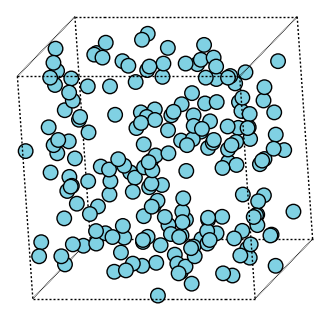

In [8]:
import matplotlib.pyplot as plt

from lammpskill import viz

if traj_rec["source"] != "skip":
    pos0 = np.array(traj_rec["frames"][0])
    cell = np.array(traj_rec["cell"])
    fig = viz.snapshot(pos0, cell, symbols=["Ar"] * len(pos0))
    plt.show()
    caption("The starting FCC lattice lj_melt() builds (a 200-atom subsample of the real "
            "4000-atom run, shown for clarity) -- every atom at its lattice site, before any "
            "dynamics. Rendered as argon-like spheres: reduced LJ units carry no real element, "
            "argon is the conventional reference fluid a reduced system is understood to stand "
            "in for, used here only to pick a rendering radius and colour, not asserted as the "
            "substance.")
else:
    print("no LAMMPS and no record: nothing to show")

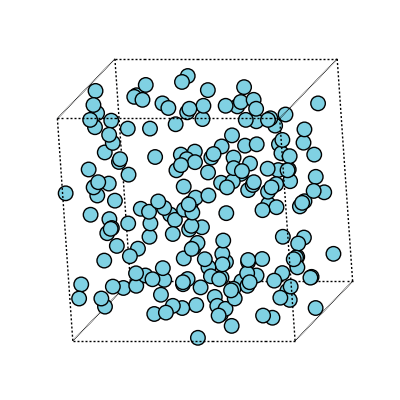

In [9]:
from IPython.display import Image, display

if traj_rec["source"] != "skip":
    frames = [np.array(f) for f in traj_rec["frames"]]
    cell = np.array(traj_rec["cell"])
    gif_workdir = tempfile.mkdtemp(prefix="ch01_gif_")
    gif_path = viz.animate_gif(frames, cell, os.path.join(gif_workdir, "melt.gif"),
                               symbols=["Ar"] * len(frames[0]), fps=4)
    display(Image(filename=gif_path))
    caption("The same subsample of atoms, animated across the run: the lattice disordering as "
            "the melt proceeds -- the same trajectory the temperature and energy curves above "
            "were read from, seen directly rather than only through its derived thermo output.")
else:
    print("no LAMMPS and no record: nothing to animate")

## Where this leaves the next chapters

The `Spec -> check -> run_or_load -> thermo` path used here is exactly what chapters 02-06 and 10
build on: `mdlite` for the numpy side of a comparison, `run_or_load` so the chapter still works
without LAMMPS, and the checker before anything runs at all.

In [10]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('all 14 checker rules were triggered by their own minimal, deliberately-flawed snippet', bool(len(missed) == 0)))
checks.append(('the lj_melt() preset carries no checker error, only two info findings', bool(all(f.level != 'error' for f in findings))))
checks.append(('run_or_load returned one of its three documented outcomes', bool(rec['source'] in ('run', 'record', 'skip'))))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 01: a claim above is not true'
print('chapter 01: %d claim(s) checked' % len(checks))

PASS all 14 checker rules were triggered by their own minimal, deliberately-flawed snippet
PASS the lj_melt() preset carries no checker error, only two info findings
PASS run_or_load returned one of its three documented outcomes
chapter 01: 3 claim(s) checked
